In [1]:
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import xarray as xr
import geopandas as gpd
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import glob
import seaborn as sns
from IPython.display import HTML
import regionmask

Suggested Figures to complete the story:
-

Bar charts statewide seasonality (monthly counts) NORMALIZED ?Hours and precip sum
- Recent climate normal statewide and Regional of focus 
- ERA5 31km and 4km (comparing)


Decadal counts storm hours --Hours and precip sum
- 4km decadal periods 1960-2010’s 
- regional and statewide 

Numbers of extremes by decade? 
- Above 5th percentile ?


Case study of exploring comparison between ASOS and ERA5 4km 
- Snotel Site Comparison
	2021 and 2011 


Loading in the Data 
-

In [2]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)

Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']

FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

In [3]:
'''path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/'
compare=f'ROS_Monthly_*.nc'
file_list = sorted(glob.glob(os.path.join(path, compare)))
combined_ds=xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')

os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')
#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)

combined_ds = combined_ds.where(oceanmask != 17)
era5_4km=combined_ds

era54kmlat = combined_ds['XLAT'].values
era54kmlon = combined_ds['XLONG'].values

ROS_Tally_era5_4km=np.sum(era5_4km['ros_tally'],axis=1)
ROS_Tally_seasonal_era5_4km=np.mean(ROS_Tally_era5_4km,axis=0)

ROS_Rain_sum_era5_4km=np.sum(era5_4km['rain_ros_sum'],axis=1)
ROS_Rain_seasonal_sum_era5_4km=np.mean(ROS_Rain_sum_era5_4km,axis=0)

lat = combined_ds['XLAT'].values
lon = combined_ds['XLONG'].values'''

'path=\'/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/\'\ncompare=f\'ROS_Monthly_*.nc\'\nfile_list = sorted(glob.glob(os.path.join(path, compare)))\ncombined_ds=xr.open_mfdataset(file_list, combine=\'by_coords\',engine=\'netcdf4\')\n\nos.chdir("/import/beegfs/CMIP6/wrf_era5")\ngeo_em_path = "geo_em.d02.nc"\ngeo = xr.open_dataset(geo_em_path)\noceanmask=geo[\'LU_INDEX\']\noceanmask=oceanmask.squeeze(dim=\'Time\')\n#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)\n\ncombined_ds = combined_ds.where(oceanmask != 17)\nera5_4km=combined_ds\n\nera54kmlat = combined_ds[\'XLAT\'].values\nera54kmlon = combined_ds[\'XLONG\'].values\n\nROS_Tally_era5_4km=np.sum(era5_4km[\'ros_tally\'],axis=1)\nROS_Tally_seasonal_era5_4km=np.mean(ROS_Tally_era5_4km,axis=0)\n\nROS_Rain_sum_era5_4km=np.sum(era5_4km[\'rain_ros_sum\'],axis=1)\nROS_Rain_seasonal_sum_era5_4km=np.mean(ROS_Rain_sum_era5_4km,axis=0)\n\nlat = combined_ds[\'XLAT\'].values\nlon = combined_ds[\'XLONG\'].values'

In [ ]:
#Regridded ERA5 31km
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)

/home/phutton5/miniconda3/envs/dyndown/lib/python3.11/site-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [5]:
os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')

era5_4km = era5_4km.where(oceanmask != 17)
regridded_era5 = regridded_era5.where(oceanmask != 17)

In [6]:
seasons=era5_4km['season']
lat=era5_4km['XLAT']
lon=era5_4km['XLONG']

At single point #not initally used but brougbt over incase I need it !

In [7]:
'''def compute_ros_hours_normalized(data):
    """Compute total ROS hours per season, number of pixels with ROS per season,
    and normalized ROS hours (total / number of pixels)
    
    seasons : season labels
    ros_hourly_totals_climatology  Total ROS hours per season
    n_pixels_per_season : Number of pixels with ROS per season
    ros_hours_normalized : Normalized ROS hours per season"""

    ros_hourly_totals_climatology = []
    n_pixels_per_season = []

    for i in range(len(data.season)):
        ros_this_season = data.isel(season=i)
        # Total ROS hours
        total = ros_this_season.sum().compute().item()
        ros_hourly_totals_climatology.append(total)
        # Count pixels with ROS (> 0)
        grid_with_ros = ros_this_season > 0
        n_pixels = grid_with_ros.sum().compute().item()
        n_pixels_per_season.append(n_pixels)

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals_climatology, n_pixels_per_season)]

    seasons = [str(s) for s in data.season.values]

    return seasons, ros_hourly_totals_climatology, n_pixels_per_season, ros_hours_normalized'''
    
    
#seasons, totals_4s, n_pixels_4s, statewide_4km_normalized = compute_ros_hours_normalized(ros_seasonal_total_4km)

#seasons, totals_31s, n_pixels_31s, statewide_31km_normalized = compute_ros_hours_normalized(ros_seasonal_total_31km)

'def compute_ros_hours_normalized(data):\n    """Compute total ROS hours per season, number of pixels with ROS per season,\n    and normalized ROS hours (total / number of pixels)\n    \n    seasons : season labels\n    ros_hourly_totals_climatology  Total ROS hours per season\n    n_pixels_per_season : Number of pixels with ROS per season\n    ros_hours_normalized : Normalized ROS hours per season"""\n\n    ros_hourly_totals_climatology = []\n    n_pixels_per_season = []\n\n    for i in range(len(data.season)):\n        ros_this_season = data.isel(season=i)\n        # Total ROS hours\n        total = ros_this_season.sum().compute().item()\n        ros_hourly_totals_climatology.append(total)\n        # Count pixels with ROS (> 0)\n        grid_with_ros = ros_this_season > 0\n        n_pixels = grid_with_ros.sum().compute().item()\n        n_pixels_per_season.append(n_pixels)\n\n    ros_hours_normalized = [\n        total / n if n > 0 else 0\n        for total, n in zip(ros_hourly_total

TESTING
-

In [32]:
def compute_ros_hours_normalized_monthly(data, month_numbers, month_labels):
    ros_hourly_totals = []
    n_pixels_per_month = []

    for m in month_numbers:
        ros_this_month = data.sel(month=m).mean(axis=0)
        total = ros_this_month.sum().compute().item()
        ros_hourly_totals.append(total)

        grid_with_ros = ros_this_month > 0
        n_pixels = grid_with_ros.sum().compute().item()
        n_pixels_per_month.append(n_pixels)

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals, n_pixels_per_month)
    ]
    return month_labels, ros_hourly_totals, n_pixels_per_month, ros_hours_normalized

In [33]:
def compute_ros_hours_normalized_monthly(data, month_numbers, month_labels):

    ros_hourly_totals = []
    n_pixels_per_month = []

    yearly_totals = {}
    yearly_n_pixels = {}
    yearly_normalized = {}

    for m, label in zip(month_numbers, month_labels):

        month_data = data.sel(month=m)

        # climatology (all years combined)
        ros_this_month = month_data.mean(dim="season")

        total = ros_this_month.sum().compute().item()
        ros_hourly_totals.append(total)

        n_pixels = (ros_this_month > 0).sum().compute().item()
        n_pixels_per_month.append(n_pixels)

        # yearly values (keep season dimension = years)
        yearly_totals[label] = (
            month_data.sum(dim=("south_north", "west_east"))
            .compute()
        )

        yearly_n_pixels[label] = (
            (month_data > 0)
            .sum(dim=("south_north", "west_east"))
            .compute()
        )

        yearly_normalized[label] = (
            yearly_totals[label] / yearly_n_pixels[label]
        )

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals, n_pixels_per_month)
    ]

    return (
        month_labels,
        ros_hourly_totals,
        n_pixels_per_month,
        ros_hours_normalized,
        yearly_totals,
        yearly_n_pixels,
        yearly_normalized,
    )

In [34]:
monthlist = ['November','December','January','February','March']
monthnumberlist = [11,12,1,2,3]

months, totals_4km, n_pixels_4km, normalized_4km = \
    compute_ros_hours_normalized_monthly(
        era5_4km['ros_tally'],
        monthnumberlist,
        monthlist
    )
    
months, totals_31km, n_pixels_31km, normalized_31km = \
    compute_ros_hours_normalized_monthly(
        regridded_era5['ros_tally'],
        monthnumberlist,
        monthlist
    )

ValueError: too many values to unpack (expected 4)

Breaking into two climate normals
- 

In [35]:
era5_4km_1951_1980 = era5_4km.sel(season=slice('1951-1952', '1980-1981'))
era5_4km_1991_2020 = era5_4km.sel(season=slice('1991-1992', '2020-2021'))
regridded_era5_1951_1980 = regridded_era5.sel(season=slice('1951-1952', '1980-1981'))
regridded_era5_1991_2020 = regridded_era5.sel(season=slice('1991-1992', '2020-2021'))

months, totals_1951_1980_31km, n_pixels_1951_1980_31km, normalized_1951_1980_31km = \
    compute_ros_hours_normalized_monthly(
        regridded_era5_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months, totals_1991_2020_31km, n_pixels_1991_2020_31km, normalized_1991_2020_31km = \
    compute_ros_hours_normalized_monthly(
        regridded_era5_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


months, totals_1951_1980_4km, n_pixels_1951_1980_4km, normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months,totals_1991_2020_4km, n_pixels_1991_2020_4km, normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


ValueError: too many values to unpack (expected 4)

To explore Bar charts and statewide seasonality 
-


Regional Analysis 
-

In [14]:
def apply_borough_mask(datasets, shapefile):
    masked_datasets = {}
    for month, data in datasets.items():
        masked = borough_land_mask(shapefile, data, data.XLAT, data.XLONG)
        masked_datasets[month] = masked
    return masked_datasets

In [15]:
def borough_land_mask(shapefile,data):
    mask = regionmask.mask_geopandas(shapefile, data.XLONG, data.XLAT)
    data_masked = data.where(~np.isnan(mask))
    return data_masked

In [ ]:
era5_4km_1951_1980 = era5_4km.sel(season=slice('1951-1952', '1980-1981'))
era5_4km_1991_2020 = era5_4km.sel(season=slice('1991-1992', '2020-2021'))

In [17]:
print((era5_4km_1951_1980 == era5_4km_1991_2020).all())

<xarray.Dataset> Size: 13B
Dimensions:              ()
Data variables: (12/13)
    ros_tally            bool 1B dask.array<chunksize=(), meta=np.ndarray>
    ros_counts           bool 1B dask.array<chunksize=(), meta=np.ndarray>
    ros_days_count       bool 1B dask.array<chunksize=(), meta=np.ndarray>
    rain_sum             bool 1B dask.array<chunksize=(), meta=np.ndarray>
    rain_ros_sum         bool 1B dask.array<chunksize=(), meta=np.ndarray>
    rain_avg             bool 1B dask.array<chunksize=(), meta=np.ndarray>
    ...                   ...
    swe_avg              bool 1B dask.array<chunksize=(), meta=np.ndarray>
    swe_ros_avg          bool 1B dask.array<chunksize=(), meta=np.ndarray>
    T2_avg               bool 1B dask.array<chunksize=(), meta=np.ndarray>
    T2_ros_avg           bool 1B dask.array<chunksize=(), meta=np.ndarray>
    temp_levels_avg      bool 1B dask.array<chunksize=(), meta=np.ndarray>
    temp_levels_ros_avg  bool 1B dask.array<chunksize=(), meta=np.

In [36]:
boundaries = {
    "bet": Bethel_boundary,
    "fai": FNSB_boundary,
    "anc": Mun_of_Anc_boundary,
    'statewide': None
}

periods = {
    "1951_1980": era5_4km_1951_1980,
    "1991_2020": era5_4km_1991_2020,
}

results = {}

for borough_name, boundary in boundaries.items():

    results[borough_name] = {}

    for period_name, ds in periods.items():
        if boundary is None:
            masked_ds = ds
        else:
            masked_ds = borough_land_mask(boundary, ds)
        (
                months,
                totals,
                n_pixels,
                normalized,
                yearly_totals,
                yearly_n_pixels,
                yearly_normalized,
        ) = compute_ros_hours_normalized_monthly(
            masked_ds["ros_tally"],
            monthnumberlist,
            monthlist,
        )

        results[borough_name][period_name] = {
            "months": months,
            "totals": totals,
            "n_pixels": n_pixels,
            "normalized": normalized,
            "yearly_totals": yearly_totals,
            "yearly_n_pixels": yearly_n_pixels,
            "yearly_normalized": yearly_normalized,
        }

In [19]:
results['statewide']

{'1951_1980': {'months': ['November',
   'December',
   'January',
   'February',
   'March'],
  'totals': [781211.4999999999,
   511505.7333333334,
   510154.50000000006,
   341134.9,
   326497.6666666666],
  'n_pixels': [101585, 87480, 99492, 82288, 82205],
  'normalized': [7.690224934783678,
   5.847116293247981,
   5.127593173320468,
   4.145621475792339,
   3.971749488068446],
  'yearly_totals': {'November': <xarray.DataArray 'ros_tally' (season: 30)> Size: 240B
   array([1068143., 1361797.,  410195., 1028998.,  338445., 1068277.,
          1448392.,  516584.,  744059.,  713467.,  631220.,  551346.,
           103195.,  639577.,  777031.,  597881., 1483343.,  604422.,
           490779., 1183651.,  377000.,  545284.,  478963.,  781415.,
           237792., 1679622.,  185266.,  999297., 1922190.,  468714.])
   Coordinates:
     * season      (season) <U9 1kB '1951-1952' '1952-1953' ... '1980-1981'
       month       int64 8B 11
       month_name  <U3 12B 'Nov',
   'December': <xarr

In [20]:
results['fai']['1991_2020']['yearly_normalized']


{'November': <xarray.DataArray 'ros_tally' (season: 30)> Size: 240B
 array([ 1.56227758,  2.29257642,  3.6068152 ,  1.67179487,  1.96884735,
                nan,  2.08064516,  1.35294118,  1.42424242,  4.29852321,
                nan,  8.43126685, 12.53619632,  1.61690141,  1.42307692,
                nan,  2.82857143,         nan,         nan, 25.69694161,
                nan,         nan,  6.13513514,  2.20396601,  4.09466812,
         1.6010929 ,         nan,  4.35805991,  5.30318471,  3.7520436 ])
 Coordinates:
   * season      (season) <U9 1kB '1991-1992' '1992-1993' ... '2020-2021'
     month       int64 8B 11
     month_name  <U3 12B 'Nov',
 'December': <xarray.DataArray 'ros_tally' (season: 30)> Size: 240B
 array([       nan, 1.46391753, 1.2734375 , 1.        , 1.24193548,
               nan,        nan,        nan, 2.73938002, 1.23913043,
               nan, 2.25507246, 1.        , 1.53867403, 3.94909502,
        1.46341463, 1.        ,        nan, 1.0952381 , 1.1       ,
    

In [21]:
std_all_boroughs = {}
for borough in results:

    all_values = []

    for month, da in results[borough]["1991_2020"]["yearly_normalized"].items():
        all_values.append(da.values)

    std_all_boroughs[borough] = np.nanstd(np.concatenate(all_values))
    
std_all_boroughs

{'bet': 8.70414528635905,
 'fai': 3.188736011128259,
 'anc': 13.303906788145849,
 'statewide': 6.150905642448422}

In [39]:
def compute_ros_hours_normalized_monthly(data, month_numbers, month_labels):

    ros_hourly_totals = []
    n_pixels_per_month = []

    yearly_totals = {}
    yearly_n_pixels = {}
    yearly_normalized = {}

    for m, label in zip(month_numbers, month_labels):

        month_data = data.sel(month=m)

        # climatology (all years combined)
        ros_this_month = month_data.mean(dim="season")

        total = ros_this_month.sum().compute().item()
        ros_hourly_totals.append(total)

        n_pixels = (ros_this_month > 0).sum().compute().item()
        n_pixels_per_month.append(n_pixels)

        # yearly values (keep season dimension = years)
        yearly_totals[label] = (
            month_data.sum(dim=("south_north", "west_east"))
            .compute()
        )

        yearly_n_pixels[label] = (
            (month_data > 0)
            .sum(dim=("south_north", "west_east"))
            .compute()
        )

        yearly_normalized[label] = (
            yearly_totals[label] / yearly_n_pixels[label]
        )

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals, n_pixels_per_month)
    ]

    return (
        month_labels,
        ros_hourly_totals,
        n_pixels_per_month,
        ros_hours_normalized,
        yearly_totals,
        yearly_n_pixels,
        yearly_normalized,
    )

In [44]:
bet_era5_4km_1951_1980=borough_land_mask(Bethel_boundary, era5_4km_1951_1980)
bet_era5_4km_1991_2020=borough_land_mask(Bethel_boundary, era5_4km_1991_2020)

months, bet_totals_1951_1980_4km, bet_n_pixels_1951_1980_4km, bet_normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        bet_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months, bet_totals_1991_2020_4km, bet_n_pixels_1991_2020_4km, bet_normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        bet_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  

fai_era5_4km_1951_1980=borough_land_mask(FNSB_boundary, era5_4km_1951_1980)
fai_era5_4km_1991_2020=borough_land_mask(FNSB_boundary, era5_4km_1991_2020)

months, fai_totals_1951_1980_4km, fai_n_pixels_1951_1980_4km, fai_normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        fai_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months, fai_totals_1991_2020_4km, fai_n_pixels_1991_2020_4km, fai_normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        fai_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


anc_era5_4km_1951_1980=borough_land_mask(Mun_of_Anc_boundary, era5_4km_1951_1980)
anc_era5_4km_1991_2020=borough_land_mask(Mun_of_Anc_boundary, era5_4km_1991_2020)


months, anc_totals_1951_1980_4km, anc_n_pixels_1951_1980_4km, anc_normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months,anc_totals_1991_2020_4km, anc_n_pixels_1991_2020_4km, anc_normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


ValueError: too many values to unpack (expected 4)

In [42]:
def compute_ros_hours_normalized_monthly(data, month_numbers, month_labels):

    ros_hourly_totals = []
    n_pixels_per_month = []

    yearly_totals = {}
    yearly_n_pixels = {}
    yearly_normalized = {}

    for m, label in zip(month_numbers, month_labels):

        month_data = data.sel(month=m)

        # ----------------------------
        # CLIMATOLOGY MAP (for diagnostics only)
        # ----------------------------
        ros_this_month = month_data.mean(dim="season")

        total = ros_this_month.sum().compute().item()
        ros_hourly_totals.append(total)

        n_pixels = (ros_this_month > 0).sum().compute().item()
        n_pixels_per_month.append(n_pixels)

        # ----------------------------
        # YEARLY VALUES (KEEP SEASON)
        # ----------------------------

        yearly_sum = month_data.sum(dim=("south_north", "west_east"))
        yearly_count = (month_data > 0).sum(dim=("south_north", "west_east"))

        yearly_normalized[label] = yearly_sum / yearly_count

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals, n_pixels_per_month)
    ]

    return (
        month_labels,
        ros_hourly_totals,
        n_pixels_per_month,
        ros_hours_normalized,
        yearly_normalized
    )
    

def mean_se(ts, dim="season"):
    ts = ts.compute()

    mean = float(ts.mean(dim=dim))
    se = float(ts.std(dim=dim, ddof=1) / np.sqrt(ts.sizes[dim]))

    return mean, se

def region_stats(yearly_dict):
    """
    Input: yearly_normalized dict (month → DataArray(season))
    Output: mean + SE per month
    """

    means = {}
    ses = {}

    for m, da in yearly_dict.items():
        means[m], ses[m] = mean_se(da, dim="season")

    return means, ses

In [43]:
months, bet_totals_50, bet_npix_50, bet_norm_50, bet_yearly_50 = \
    compute_ros_hours_normalized_monthly(
        bet_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist
    )

bet_mean_50, bet_se_50 = region_stats(bet_yearly_50)

months, fai_totals_50, fai_npix_50, fai_norm_50, fai_yearly_50 = \
    compute_ros_hours_normalized_monthly(
        fai_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist
    )

fai_mean_50, fai_se_50 = region_stats(fai_yearly_50)

months, anc_totals_50, anc_npix_50, anc_norm_50, anc_yearly_50 = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist
    )

anc_mean_50, anc_se_50 = region_stats(anc_yearly_50)


bet_mean_90, bet_se_90 = region_stats(
    compute_ros_hours_normalized_monthly(
        bet_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist
    )[4]
)


NameError: name 'fai_era5_4km_1951_1980' is not defined

NameError: name 'anc_normalized_1951_1980_4km' is not defined

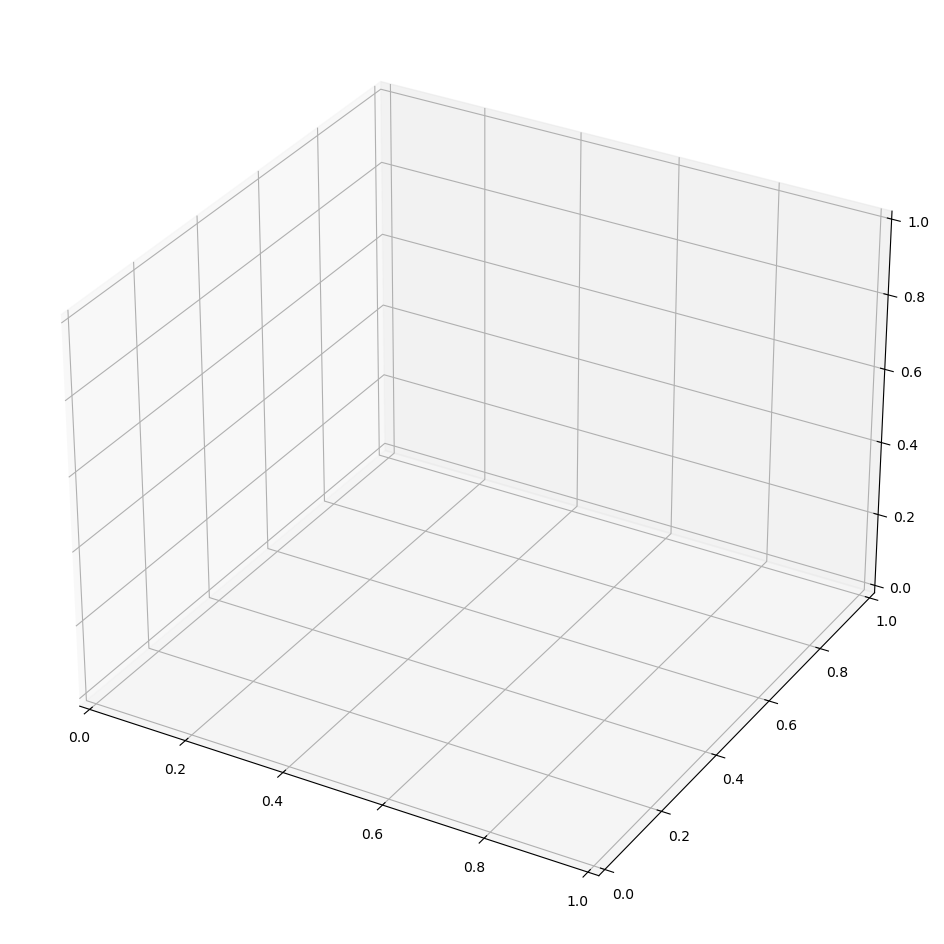

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessary for 3D plotting
from matplotlib.patches import Patch

borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
x = np.arange(len(month_labels))
width = 0.3
depth = 0.3 


fig = plt.figure(figsize=(25, 12)) 
ax = fig.add_subplot(111, projection='3d')


offsets = {"1951-1980": -0.1,
        "1991-2020": 0.15}

y_positions = {
    "Fairbanks": 0,
    "Anchorage": 3,
    'Statewide': 1,
    "Bethel": 2
}
# ---- Anchorage ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, anc_normalized_1951_1980_4km, 
         color=borough_colors["Anchorageold"],  edgecolor='black', label='Anchorage 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, anc_normalized_1991_2020_4km, 
         color=borough_colors["Anchoragenew"], edgecolor='black', label='Anchorage 1991-2020')
#---- Statewide ----

ax.bar3d(x + offsets["1951-1980"], y_positions["Statewide"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, normalized_1951_1980_4km, 
         color=borough_colors["Statewideold"],  edgecolor='black', label='Statewide 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Statewide"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, normalized_1991_2020_4km, 
         color=borough_colors["Statewidenew"], edgecolor='black', label='Statewide 1991-2020')


# ---- Fairbanks ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Fairbanks"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, fai_normalized_1951_1980_4km, 
         color=borough_colors["Fairbanksold"],  edgecolor='black', label='Fairbanks 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Fairbanks"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, fai_normalized_1991_2020_4km, 
         color=borough_colors["Fairbanksnew"], edgecolor='black', label='Fairbanks 1991-2020')

# ---- Bethel ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Bethel"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, bet_normalized_1951_1980_4km, 
         color=borough_colors["Bethelold"], edgecolor='black', label='Bethel 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Bethel"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, bet_normalized_1991_2020_4km, 
         color=borough_colors["Bethelnew"], edgecolor='black', label='Bethel 1991-2020')


# Set axis labels
ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=15)

yticks = [0.2, 1.2, 2.2, 3.2]
labels = ['Fairbanks','Statewide','Bethel','Anchorage']
ax.set_yticklabels([])
ax.set_yticks(yticks)

for y, label in zip(yticks, labels):
    ax.text(x[-1]+1.2 , y-.5, 2, label, fontsize=15, ha='left', va='center')

#ax.set_yticks([0.2,1.2,2.2,3.2])
#ax.set_yticklabels(['  Fairbanks','   Statewide','Bethel','    Anchorage'], fontsize=12)
#ax.set_zlabel('Average Hours of ROS (hr)', fontsize=12, rotation=90)
ax.tick_params(axis='z', labelsize=15)
fig.text(0.71, 0.55, 'Average Hours of ROS (hr)', rotation=90, fontsize=15, va='center', ha='center')
#ax.set_title('Average Hours of ROS by Borough\n(Normalized by Active Area)', y=0.99,fontsize=15)

#ax.set_title('Average Hours of ROS', fontsize=18, pad=20,y=.99)  
#fig.text(0.5, 0.84, 'Normalized by Active Area', ha='center', fontsize=14)

fig.text(.5, .1, "Left Bar = 1951–1980     Right Bar = 1991–2020", ha='center', fontsize=13)
fig.text(0.4, 0.77, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
fig.patch.set_alpha(0.0)
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Anchorage
anc_pct_change = (np.array(anc_normalized_1991_2020_4km) -
                  np.array(anc_normalized_1951_1980_4km)) \
                 / np.array(anc_normalized_1951_1980_4km) * 100

# Fairbanks
fai_pct_change = (np.array(fai_normalized_1991_2020_4km) -
                  np.array(fai_normalized_1951_1980_4km)) \
                 / np.array(fai_normalized_1951_1980_4km) * 100

# Bethel
bet_pct_change = (np.array(bet_normalized_1991_2020_4km) -
                  np.array(bet_normalized_1951_1980_4km)) \
                 / np.array(bet_normalized_1951_1980_4km) * 100

# Statewide
state_pct_change = (np.array(normalized_1991_2020_4km) -
                    np.array(normalized_1951_1980_4km)) \
                   / np.array(normalized_1951_1980_4km) * 100
print(anc_pct_change)
print(fai_pct_change)
print(bet_pct_change)

print(state_pct_change)


# build matrix (rows = regions, cols = months)
heatmap_data = np.array([
    fai_pct_change,
    state_pct_change,
    bet_pct_change,
    anc_pct_change
])

months = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(heatmap_data, cmap='RdBu_r', aspect='auto')

# axes labels
ax.set_xticks(np.arange(len(months)))
ax.set_xticklabels(months)

ax.set_yticks(np.arange(4))
ax.set_yticklabels(['Fairbanks',  'Statewide','Bethel','Anchorage'])

# value labels
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(j, i, f"{heatmap_data[i, j]:.1f}",
                ha='center', va='center', fontsize=10)

# colorbar + title
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('% Change (1991–2020 vs 1951–1980)')

ax.set_title('Percent Change in ROS Hours by Region and Month')

plt.tight_layout()
plt.show()

NameError: name 'anc_normalized_1991_2020_4km' is not defined

In [28]:
anc_era5_4km_1951_1980=borough_land_mask(Mun_of_Anc_boundary, era5_4km_1951_1980)
anc_era5_4km_1991_2020=borough_land_mask(Mun_of_Anc_boundary, era5_4km_1991_2020)
anc_regridded_era5_1951_1980=borough_land_mask(Mun_of_Anc_boundary, regridded_era5_1951_1980)
anc_regridded_era5_1991_2020=borough_land_mask(Mun_of_Anc_boundary, regridded_era5_1991_2020)


months, and_totals_1951_1980_31km, anc_n_pixels_1951_1980_31km, anc_normalized_1951_1980_31km = \
    compute_ros_hours_normalized_monthly(
        anc_regridded_era5_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months, anc_totals_1991_2020_31km, anc_n_pixels_1991_2020_31km, anc_normalized_1991_2020_31km = \
    compute_ros_hours_normalized_monthly(
        anc_regridded_era5_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  

months, anc_totals_1951_1980_4km, anc_n_pixels_1951_1980_4km, anc_normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months,anc_totals_1991_2020_4km, anc_n_pixels_1991_2020_4km, anc_normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


ValueError: too many values to unpack (expected 4)

In [ ]:
anc_1951_seasonal_ros=np.sum(anc_normalized_1951_1980_4km)
anc_1991_seasonal_ros=np.sum(anc_normalized_1991_2020_4km)

bet_1951_seasonal_ros=np.sum(bet_normalized_1951_1980_4km)
bet_1991_seasonal_ros=np.sum(bet_normalized_1991_2020_4km)

fai_1951_seasonal_ros=np.sum(fai_normalized_1951_1980_4km)
fai_1991_seasonal_ros=np.sum(fai_normalized_1991_2020_4km)

statewide_1951_seasonal_ros=np.sum(normalized_1951_1980_4km)
statewide_1991_seasonal_ros=np.sum(normalized_1991_2020_4km)


NameError: name 'anc_normalized_1951_1980_4km' is not defined

In [ ]:
anc_1951_seasonal_ros

75.22683781983459

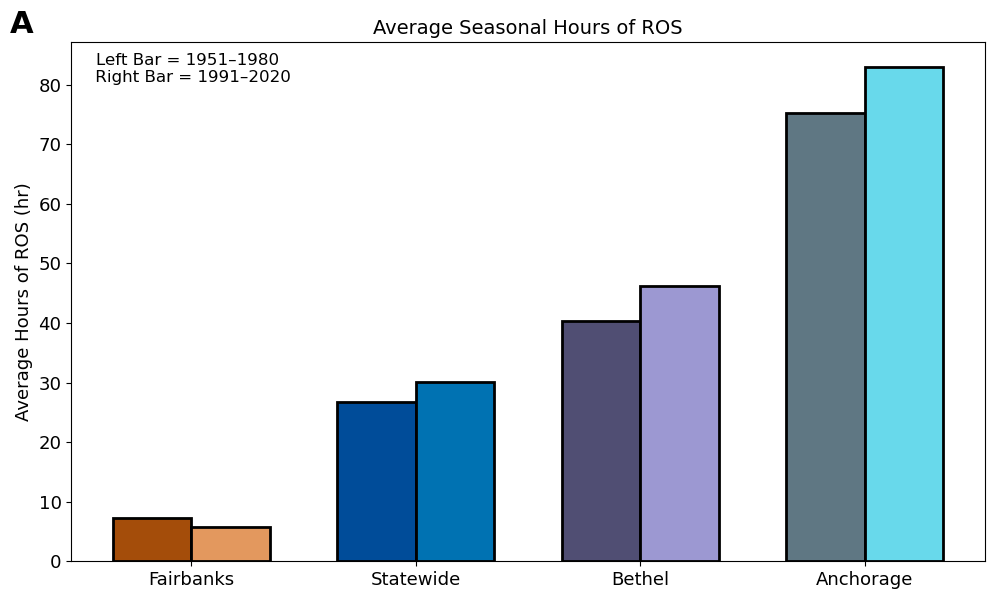

In [ ]:

borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

labels = ['Fairbanks','Statewide','Bethel','Anchorage']
x = np.arange(len(labels))
width = 0.35  # width of each bar

# Values per period
old_ros = [fai_1951_seasonal_ros, statewide_1951_seasonal_ros, bet_1951_seasonal_ros, anc_1951_seasonal_ros]
new_ros = [fai_1991_seasonal_ros, statewide_1991_seasonal_ros, bet_1991_seasonal_ros, anc_1991_seasonal_ros]

fig, ax = plt.subplots(figsize=(10,6))

# Plot bars
ax.bar(x - width/2, old_ros, width, color=[borough_colors['Fairbanksold'], borough_colors['Statewideold'], borough_colors['Bethelold'], borough_colors['Anchorageold']], edgecolor='black',  linewidth=2, label='1951-1980')
ax.bar(x + width/2, new_ros, width, color=[borough_colors['Fairbanksnew'], borough_colors['Statewidenew'], borough_colors['Bethelnew'], borough_colors['Anchoragenew']], edgecolor='black',   linewidth=2,label='1991-2020')

# Labels
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=13)
ax.set_ylabel('Average Hours of ROS (hr)',fontsize=13)
ax.set_title('Average Seasonal Hours of ROS', fontsize=14)
ax.tick_params(axis='y', labelsize=13)
fig.text(0.19, 0.87, "Left Bar = 1951–1980 \n Right Bar = 1991–2020", ha='center', fontsize=12)
fig.text(0.01, 0.99, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
plt.tight_layout()
plt.show()

In [29]:
std_all_boroughs_1991 = {}
for borough in results:

    all_values = []

    for month, da in results[borough]["1991_2020"]["yearly_normalized"].items():
        all_values.append(da.values)
    std_all_boroughs_1991[borough] = np.nanstd(np.concatenate(all_values))    
std_all_boroughs_1991

std_all_boroughs_1951 = {}
for borough in results:

    all_values = []

    for month, da in results[borough]["1951_1980"]["yearly_normalized"].items():
        all_values.append(da.values)
    std_all_boroughs_1951[borough] = np.nanstd(np.concatenate(all_values))

std_all_boroughs_1951

{'bet': 8.700052978140073,
 'fai': 3.710980119311043,
 'anc': 14.266379759640747,
 'statewide': 5.996945700513454}

In [30]:
old_uncertainty = {
    'bet': 8.700052978140073,
    'fai': 3.710980119311043,
    'anc': 14.266379759640747,
    'statewide': 5.996945700513454
}

new_uncertainty = {
    'bet': 8.70414528635905,
    'fai': 3.188736011128259,
    'anc': 13.303906788145849,
    'statewide': 6.150905642448422
}



unc_old = [old_uncertainty['fai'],
           old_uncertainty['statewide'],
           old_uncertainty['bet'],
           old_uncertainty['anc']]

unc_new = [new_uncertainty['fai'],
           new_uncertainty['statewide'],
           new_uncertainty['bet'],
           new_uncertainty['anc']]


borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

labels = ['Fairbanks','Statewide','Bethel','Anchorage']
x = np.arange(len(labels))
width = 0.35  # width of each bar

# Values per period
old_ros = [fai_1951_seasonal_ros, statewide_1951_seasonal_ros, bet_1951_seasonal_ros, anc_1951_seasonal_ros]
new_ros = [fai_1991_seasonal_ros, statewide_1991_seasonal_ros, bet_1991_seasonal_ros, anc_1991_seasonal_ros]

fig, ax = plt.subplots(figsize=(10,6))

# Plot bars
#ax.bar(x - width/2, old_ros, width, color=[borough_colors['Fairbanksold'], borough_colors['Statewideold'], borough_colors['Bethelold'], borough_colors['Anchorageold']], edgecolor='black',  linewidth=2, label='1951-1980')
#ax.bar(x + width/2, new_ros, width, color=[borough_colors['Fairbanksnew'], borough_colors['Statewidenew'], borough_colors['Bethelnew'], borough_colors['Anchoragenew']], edgecolor='black',   linewidth=2,label='1991-2020')

ax.bar(
    x - width/2,
    old_ros,
    width,
    yerr=unc_old,
    capsize=5,
    color=[borough_colors['Fairbanksold'],
           borough_colors['Statewideold'],
           borough_colors['Bethelold'],
           borough_colors['Anchorageold']],
    edgecolor='black',
    linewidth=2,
    label='1951-1980'
)

ax.bar(
    x + width/2,
    new_ros,
    width,
    yerr=unc_new,
    capsize=5,
    color=[borough_colors['Fairbanksnew'],
           borough_colors['Statewidenew'],
           borough_colors['Bethelnew'],
           borough_colors['Anchoragenew']],
    edgecolor='black',
    linewidth=2,
    label='1991-2020'
)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=13)
ax.set_ylabel('Average Hours of ROS (hr)',fontsize=13)
ax.set_title('Average Seasonal Hours of ROS', fontsize=14)
ax.tick_params(axis='y', labelsize=13)
fig.text(0.19, 0.87, "Left Bar = 1951–1980 \n Right Bar = 1991–2020", ha='center', fontsize=12)
fig.text(0.01, 0.99, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
plt.tight_layout()
fig.patch.set_alpha(0.0)
plt.show()

NameError: name 'fai_1951_seasonal_ros' is not defined